[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AstroAI-CfA/tutorial-lsdb/blob/main/tutorials/Notebook_2_Solution.ipynb)

Author: Konstantin Malanchev and the LINCC Frameworks team

Last updated: June 2026

# Solution: Predict $T_{\rm eff}$ from Gaia Colors

This notebook is the solution to Problem 2 from `Notebook_2_Crossmatch.ipynb`.

We use the Gaia DR3 x APOGEE DR17 cross-match to train a small neural network
(`MLPRegressor`) that predicts spectroscopic effective temperature from Gaia
photometric colors and APOGEE $J-H$ color. To minimise dust reddening we
restrict to stars at galactic latitude $b < -15^\circ$. The model is trained
incrementally with `partial_fit` as partitions stream in. A random subset of
partitions is held out as the test set; the remaining partitions are used for training.

In [1]:
# do you need to install the packages?
# if yes, uncomment the line below and restart the kernel
# %pip install -U lsdb s3fs huggingface_hub scikit-learn tqdm

In [2]:
import io
import logging
import os
from pathlib import Path
import warnings

# Must be set before importing packages that use numexpr
os.environ["NUMEXPR_MAX_THREADS"] = "2"

import dask
import lsdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from dask.distributed import Client
from lsdb.streams import CatalogStream
from matplotlib import rcParams
from PIL import Image

%matplotlib inline

warnings.simplefilter("ignore")
logging.getLogger("numexpr.utils").setLevel(logging.WARNING)
logging.getLogger("distributed").setLevel(logging.WARNING)
rcParams["savefig.dpi"] = 550
rcParams["font.size"] = 20
plt.rc("font", family="serif")
mpl.rcParams["axes.linewidth"] = 2
dask.config.set({"dataframe.convert-string": False})

print(f"Version of lsdb is {lsdb.__version__}")

Version of lsdb is 0.9.2


## Setup Dask cluster

In [3]:
client = Client(n_workers=2, memory_limit="4GiB", threads_per_worker=1)
print(f"Dask is running at: {client.dashboard_link}")

Dask is running at: http://127.0.0.1:54999/status


## Load the Catalogs

To get clean photometric colors we need stars with low dust extinction.
Extinction is concentrated in the galactic plane, so we restrict to
galactic latitude $b < -15^\circ$.

Rather than computing $b$ for every star, we exploit the geometry: the south
galactic pole is at RA = 12.86 deg, Dec = -27.13 deg. A cone of radius 75 deg
around it covers exactly the region $b < -15^\circ$.

Three colors serve as model features (two from Gaia, one from APOGEE):
- `bp_rp` ($G_{\rm BP} - G_{\rm RP}$) -- pre-computed in the Gaia catalog
- `g_rp` ($G - G_{\rm RP}$) -- derived via `map_partitions` on Gaia
- `j_h` ($J - H$) -- derived via `map_partitions` on APOGEE; $J$ and $H$ are near-IR magnitudes

In [4]:
gaia = lsdb.open_catalog(
    "s3://stpubdata/gaia/gaia_dr3/public/hats",
    columns=["source_id", "ra", "dec", "parallax", "parallax_over_error",
             "phot_g_mean_mag", "phot_rp_mean_mag", "bp_rp"],
    search_filter=lsdb.ConeSearch(ra=12.86, dec=-27.13, radius_arcsec=75 * 3600),
).query("parallax_over_error > 30 and parallax > 0 and 5 < phot_rp_mean_mag < 22 and -1 < bp_rp < 6")

gaia = gaia.map_partitions(
    lambda df: df.assign(
        abs_g=df["phot_g_mean_mag"] + 5 * np.log10(df["parallax"]) - 10,
        g_rp=df["phot_g_mean_mag"] - df["phot_rp_mean_mag"],
    )
)

apogee = lsdb.open_catalog(
    "hf://datasets/hugging-science/mmu_apogee_dr17/mmu_apogee_dr17",
    columns=["ra", "dec", "teff", "teff_err", "logg", "fe_h", "j", "h"],
).query("teff > 0 and teff_err < 100 and fe_h == fe_h and 5 < j < 20 and 5 < h < 20")

apogee = apogee.map_partitions(
    lambda df: df.assign(j_h=df["j"] - df["h"])
)

print(f"Gaia partitions:   {len(gaia.get_healpix_pixels())}")
print(f"APOGEE partitions: {len(apogee.get_healpix_pixels())}")

Gaia partitions:   270
APOGEE partitions: 1820


## Cross-Match

`catalog.crossmatch()` spatially joins two HATS catalogs partition-by-partition using a KD-tree to find the nearest APOGEE neighbour within `radius_arcsec` for each Gaia source.

With `suffix_method="overlapping_columns"` only the columns present in both catalogs (`ra` and `dec`) get suffixed; unique columns like `parallax`, `phot_g_mean_mag`, and `teff` keep their original names.

+--------+---------------------+------------------------+
| Column | Left (suffix=_gaia) | Right (suffix=_apogee) |
+--------+---------------------+------------------------+
|  dec   |      dec_gaia       |       dec_apogee       |
|   ra   |       ra_gaia       |       ra_apogee        |
+--------+---------------------+------------------------+


Cross-matched catalog columns:
['source_id', 'ra_gaia', 'dec_gaia', 'parallax', 'parallax_over_error', 'phot_g_mean_mag', 'phot_rp_mean_mag', 'bp_rp', 'abs_g', 'g_rp', 'ra_apogee', 'dec_apogee', 'teff', 'teff_err', 'logg', 'fe_h', 'j', 'h', 'j_h', '_dist_arcsec']
Total partitions: 496


,source_id,ra_gaia,dec_gaia,parallax,parallax_over_error,phot_g_mean_mag,phot_rp_mean_mag,bp_rp,abs_g,g_rp,ra_apogee,dec_apogee,teff,teff_err,logg,fe_h,j,h,j_h,_dist_arcsec
npartitions=496,,,,,,,,,,,,,,,,,,,,
"Order: 4, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow]
"Order: 7, Pixel: 234",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 3070",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 3071",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


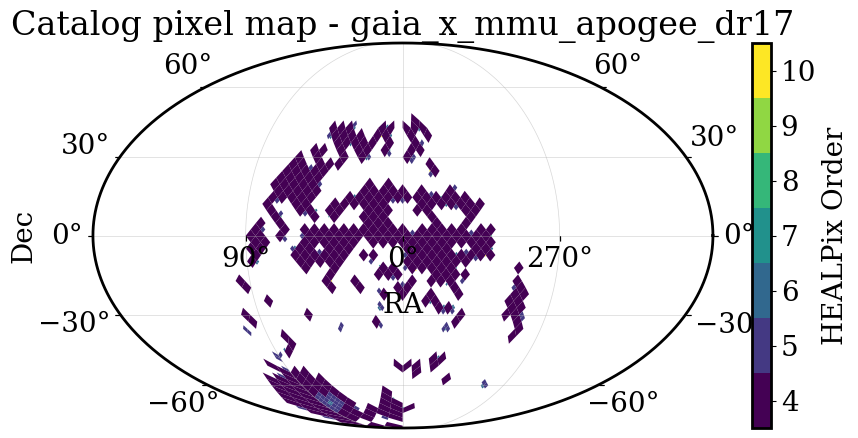

In [5]:
xmatch = gaia.crossmatch(
    apogee,
    radius_arcsec=1.0,
    suffixes=("_gaia", "_apogee"),
    suffix_method="overlapping_columns",
)

print("Cross-matched catalog columns:")
print(xmatch.columns.tolist())
print(f"Total partitions: {len(xmatch.get_healpix_pixels())}")
xmatch.plot_pixels()
xmatch

## Problem 2: Predict $T_{\rm eff}$ from Gaia Colors

The cross-matched catalog pairs each star's APOGEE spectroscopic temperature with its
Gaia photometric colors. Effective temperature correlates tightly with color, so a
simple model trained on photometry alone can recover it.

**Your task:** train a model on the streaming cross-match to predict `teff` from
Gaia colors, and evaluate how well it does.

**Steps:**
1. Use the `xmatch` catalog already built above. Features: `bp_rp`
   ($G_{\rm BP} - G_{\rm RP}$) and `g_rp` ($G - G_{\rm RP}$). Target: `teff`.
2. Stream `xmatch` with `CatalogStream`. Hold a random subset of partitions
   out as a test set; train on the rest.
3. After streaming, predict on the test set and plot predicted vs APOGEE $T_{\rm eff}$.
   Report $R^2$ and MAE.

**Advanced:** add `j_h` ($J - H$ from APOGEE) as a third feature. Does it improve the predictions?


## Solution

We use `MLPRegressor` (a small one-hidden-layer neural network) with `partial_fit`
for online updates. Features and target are standardized with `StandardScaler`
(also online). `N_TEST` randomly chosen partitions are held out as the test set;
`N_TRAIN` randomly chosen partitions train the model one chunk at a time.

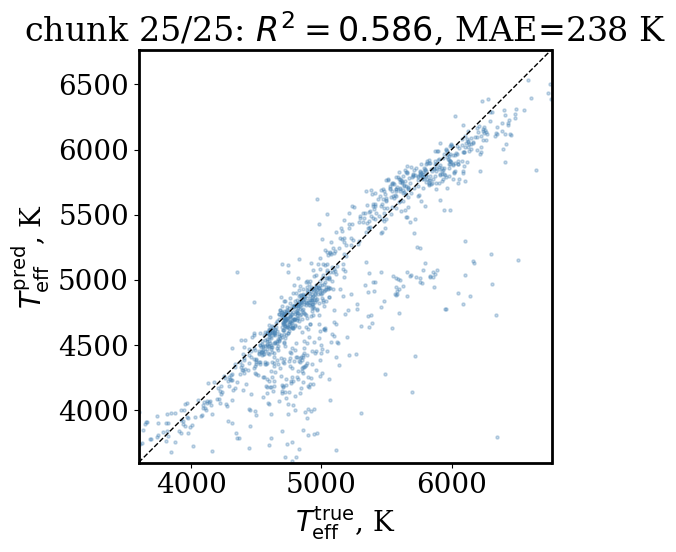

Test stars: 1,118  |  final R2=0.586, MAE=238 K
CPU times: user 8.15 s, sys: 1.68 s, total: 9.83 s
Wall time: 2min 58s


In [6]:
%%time
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

FEATURES = ["bp_rp", "g_rp", "j_h"]
N_TEST = 5
N_TRAIN = 50

rng = np.random.default_rng(42)
idx = rng.choice(xmatch.npartitions, size=N_TEST + N_TRAIN, replace=False)
test_idx, train_idx = idx[:N_TEST], idx[N_TEST:]

test_df = xmatch.partitions[test_idx].compute()
test_X = test_df[FEATURES].to_numpy(dtype=float)
test_y = test_df["teff"].to_numpy(dtype=float)
ok = np.isfinite(test_X).all(axis=1) & np.isfinite(test_y)
test_X, test_y = test_X[ok], test_y[ok]

feat_scaler = StandardScaler()
tgt_scaler = StandardScaler()
model = MLPRegressor(
    hidden_layer_sizes=(32,),
    learning_rate="adaptive",
    learning_rate_init=0.01,
    max_iter=1,
    random_state=42,
)

teff_lims = [test_y.min(), test_y.max()]
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlabel(r"$T_{\rm eff}^{\rm true}$, K")
ax.set_ylabel(r"$T_{\rm eff}^{\rm pred}$, K")
ax.set_xlim(teff_lims)
ax.set_ylim(teff_lims)
ax.set_aspect("equal")
ax.plot(teff_lims, teff_lims, "k--", lw=1)
scatter = ax.scatter([], [], s=5, alpha=0.3, rasterized=True, color="steelblue")
plt.tight_layout()
fig_handle = display(fig, display_id=True)

frames = []
for i, chunk in enumerate(CatalogStream(xmatch.partitions[train_idx], partitions_per_chunk=2), start=1):
    X = chunk[FEATURES].to_numpy(dtype=float)
    y = chunk["teff"].to_numpy(dtype=float)
    ok = np.isfinite(X).all(axis=1) & np.isfinite(y)
    X, y = X[ok], y[ok]
    if len(X) == 0:
        continue

    feat_scaler.partial_fit(X)
    tgt_scaler.partial_fit(y.reshape(-1, 1))
    model.partial_fit(
        feat_scaler.transform(X),
        tgt_scaler.transform(y.reshape(-1, 1)).ravel(),
    )

    pred_y = tgt_scaler.inverse_transform(
        model.predict(feat_scaler.transform(test_X)).reshape(-1, 1)
    ).ravel()
    r2 = r2_score(test_y, pred_y)
    mae = mean_absolute_error(test_y, pred_y)

    scatter.set_offsets(np.column_stack([test_y, pred_y]))
    ax.set_title(f"chunk {i}/{(N_TRAIN+1)//2}: $R^2={r2:.3f}$, MAE={mae:.0f} K")
    fig_handle.update(fig)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=80)
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()

plt.close(fig)
print(f"Test stars: {len(test_y):,}  |  final R2={r2:.3f}, MAE={mae:.0f} K")

In [7]:
gif_path = Path("images") / "teff_prediction.gif"
gif_path.parent.mkdir(exist_ok=True)
if frames:
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=350,
        loop=0,
    )
    print(f"Saved {len(frames)}-frame GIF -> {gif_path}")

Saved 25-frame GIF -> images/teff_prediction.gif


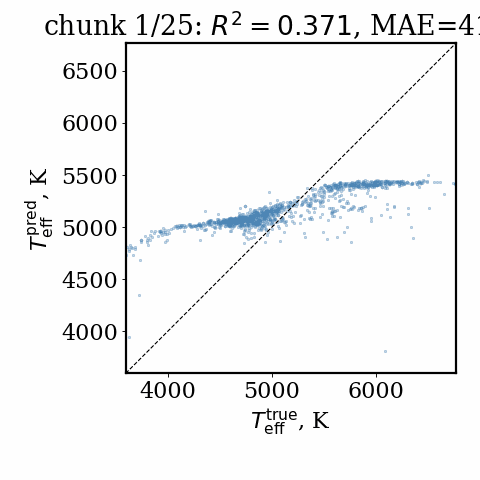

In [8]:
from IPython.display import Image as IPImage
IPImage(filename=gif_path)

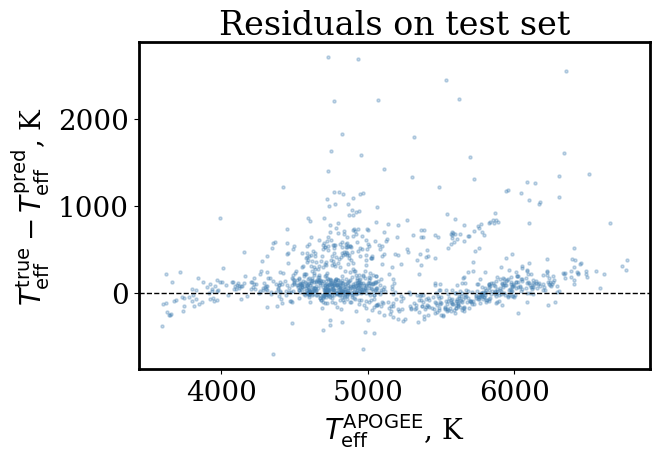

In [9]:
residuals = test_y - pred_y

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(test_y, residuals, s=5, alpha=0.3, rasterized=True, color="steelblue")
ax.axhline(0, color="k", lw=1, ls="--")
ax.set_xlabel(r"$T_{\rm eff}^{\rm APOGEE}$, K")
ax.set_ylabel(r"$T_{\rm eff}^{\rm true} - T_{\rm eff}^{\rm pred}$, K")
ax.set_title("Residuals on test set")
plt.tight_layout()
plt.show()

In [10]:
client.close()